In [43]:
import pandas as pd

df = pd.read_csv("data/student-por.csv")
df.head()
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10
648,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,4,10,11,11


In [3]:
#데이터 기본확인
df.shape

(649, 33)

In [4]:
df.info

<bound method DataFrame.info of     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
644     MS   F   19       R     GT3       T     2     3  services     other   
645     MS   F   18       U     LE3       T     3     1   teacher  services   
646     MS   F   18       U     GT3       T     1     1     other     other   
647     MS   M   17       U     LE3       T     3     1  services  services   
648     MS   M   18       R     LE3       T     3     2  services     other   

     ... famrel fre

In [42]:
df.isnull().sum()

school         0
sex            0
age            0
address        0
famsize        0
Pstatus        0
Medu           0
Fedu           0
Mjob           0
Fjob           0
reason         0
guardian       0
traveltime     0
studytime      0
failures       0
schoolsup      0
famsup         0
paid           0
activities     0
nursery        0
higher         0
internet       0
romantic       0
famrel         0
freetime       0
goout          0
Dalc           0
Walc           0
health         0
absences       0
G1             0
G2             0
G3             0
grade_group    0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [6]:
#컬럼 대상 확인
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [7]:
#예측 대상 확인
df[["G1", "G2", "G3"]].head()

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

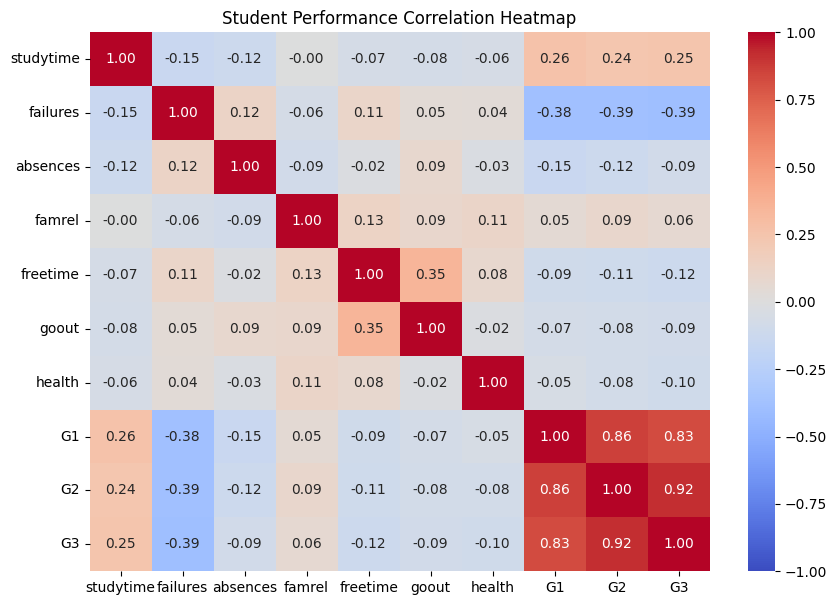

In [9]:
#주요 변수 상관관계 Heatmap
corr_cols = [
    "studytime", "failures", "absences",
    "famrel", "freetime", "goout", "health",
    "G1","G2","G3"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",vmin=-1,vmax=1)
plt.title("Student Performance Correlation Heatmap")
plt.show()

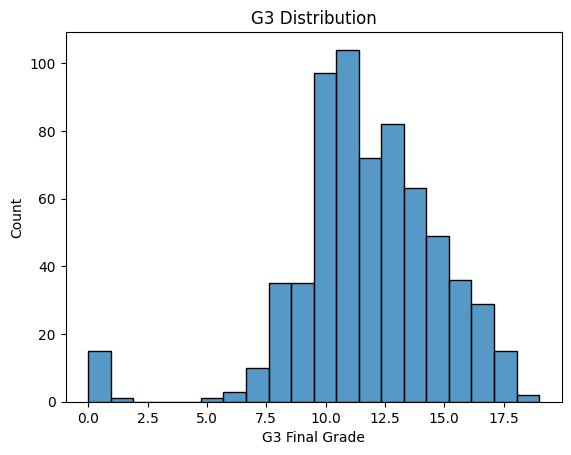

In [10]:
#G3 최종 성적 분포 확인하기
sns.histplot(df["G3"], bins=20)
plt.title("G3 Distribution")
plt.xlabel("G3 Final Grade")
plt.ylabel("Count")
plt.show()
#최종 성적 G3의 분포를 확인한 결과, 학생들의 성적이 특정 점수 구간에 집중되어 있는지 확인할 수 있었다.

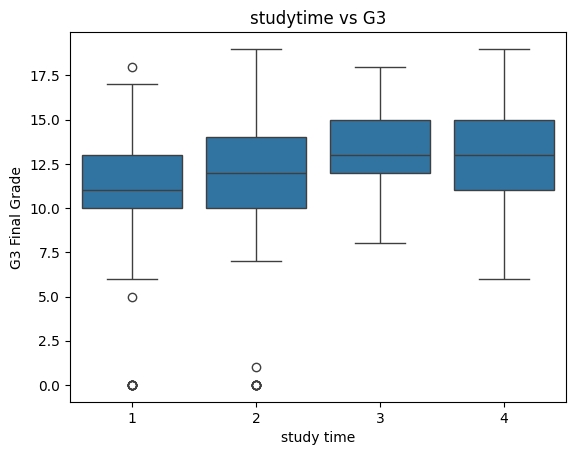

In [11]:
#공부시간과 최종 성적 관계 보기
sns.boxplot(data=df, x="studytime", y="G3")
plt.title("studytime vs G3")
plt.xlabel("study time")
plt.ylabel("G3 Final Grade")
plt.show()
#studytime의 의미: 1 = 주 2시간 미만, 2 = 주 2~5시간 , 3 = 주 5~10시간, 4 = 주 10시간 이상

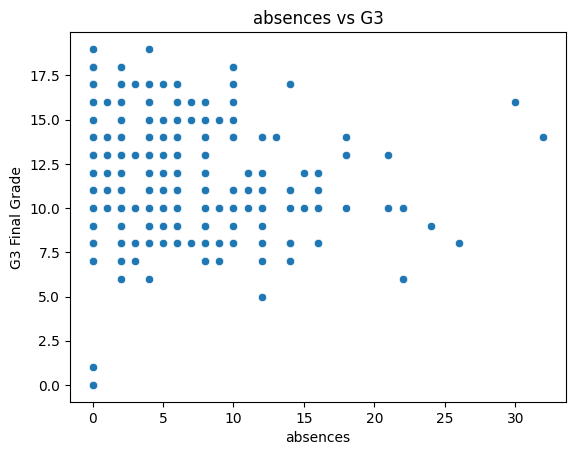

In [12]:
#결석일수와 최종 성적 관계 보기
sns.scatterplot(data=df, x="absences", y="G3")
plt.title("absences vs G3")
plt.xlabel("absences")
plt.ylabel("G3 Final Grade")
plt.show()
#산점도: 두 숫자 변수의 관계를 점으로 보는 그래프, 결석일수가 많을수록 성적이 낮아지는 경향이 있는지 확인한다.

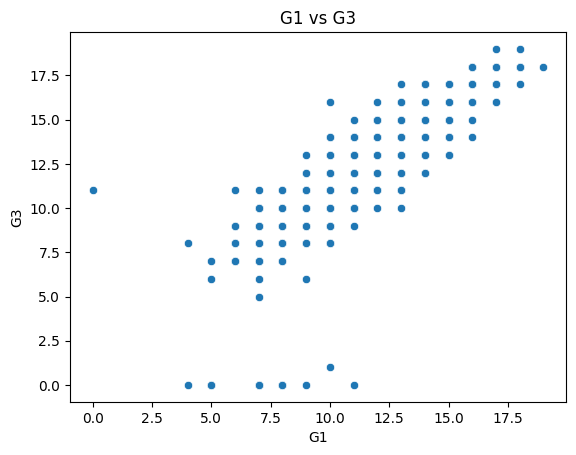

In [13]:
#G1,G2,G3 관계 보기
sns.scatterplot(data=df, x="G1", y="G3")
plt.title("G1 vs G3")
plt.xlabel("G1")
plt.ylabel("G3")
plt.show()

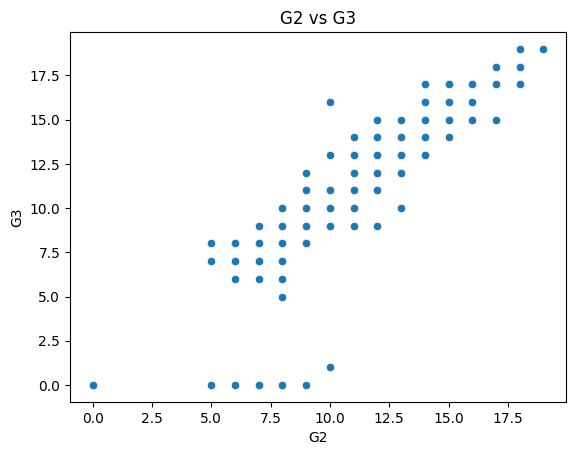

In [14]:
sns.scatterplot(data=df, x="G2", y="G3")
plt.title("G2 vs G3")
plt.xlabel("G2")
plt.ylabel("G3")
plt.show()

In [15]:
#학업 수준 그룹 만들기, 분류용 컬럼 만드는것
def grade_group(score):
    if score <= 9:
        return "위험"
    elif score <= 14:
        return "보통"
    else:
        return "우수"
df["grade_group"] = df["G3"].apply(grade_group)

df[["G3", "grade_group"]].head()

,G3,grade_group
0,11,보통
1,11,보통
2,12,보통
3,14,보통
4,13,보통


In [16]:
#그룹 개수 확인
df["grade_group"].value_counts()

grade_group
보통    418
우수    131
위험    100
Name: count, dtype: int64

C:\Users\human-05\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\human-05\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\human-05\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\human-05\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\human-05\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWar

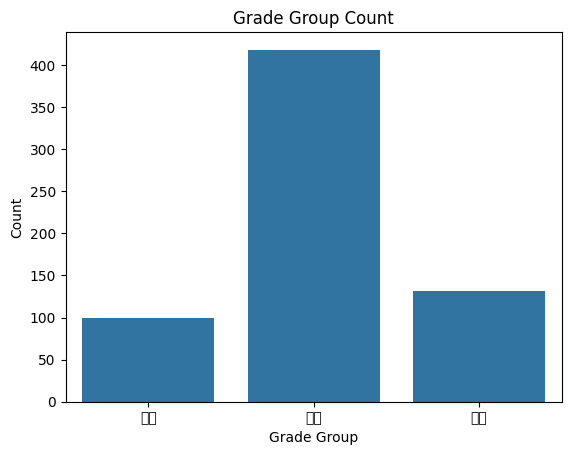

In [17]:
#그룹 개수 확인 - 그래프로도 확인
sns.countplot(data=df, x="grade_group", order=["위험", "보통", "우수"])
plt.title("Grade Group Count")
plt.xlabel("Grade Group")
plt.ylabel("Count")
plt.show()

In [18]:
#모델 A/B용 변수 나누기, 입력값과 정답값을 나눌 준비하기
y_reg = df["G3"]
y_clf = df["grade_group"]

In [19]:
#모델 A/B 컬럼 나누기
target_cols = ["G3","grade_group"]

model_b_extra_cols = ["G1", "G2"]

X_A = df.drop(columns=target_cols + model_b_extra_cols)
X_B = df.drop(columns=target_cols)

print("Model A colums:", X_A.columns.tolist())
print("Model B colums:", X_B.columns.tolist())

Model A colums: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Model B colums: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [20]:
#모델 인코딩하기
X_A_encoded = pd.get_dummies(X_A, drop_first=True)
X_B_encoded = pd.get_dummies(X_B, drop_first=True)

print(X_A_encoded.shape)
print(X_B_encoded.shape)
#drop_first -> 중복을 줄이는 옵션: 비슷한 의미의 컬럼이 너무 많이 생기는걸 줄이기 위해 첫 번째 기준 컬럼을 하나 빼는 옵션

(649, 39)
(649, 41)


In [21]:
#회귀용 train/ test split
from sklearn.model_selection import train_test_split

X_A_train, X_A_test, y_reg_train, y_reg_test = train_test_split(
    X_A_encoded, y_reg, test_size=0.2, random_state=42
)

X_B_train, X_B_test, y_reg_train_B, y_reg_test_B = train_test_split(
    X_B_encoded, y_reg, test_size=0.2, random_state=42
)
#train: 모델이 공부하는 데이터
#test: 모델이 처음 보는 시험 데이터
#test_size=0.2는 전체 데이터중 20%를 테스트용으로 사용

In [44]:
#선형 회귀 모델 학습
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#모델A
lr_A = LinearRegression()
lr_A.fit(X_A_train, y_reg_train)
pred_A = lr_A.predict(X_A_test)

#모델B
lr_B = LinearRegression()
lr_B.fit(X_B_train, y_reg_train_B)
pred_B = lr_B.predict(X_B_test)
#fit: 모델을 학습시키는 것
#predict: 학습한 모델로 예측하는 것

In [23]:
#회귀 성능 평가 함수 만들기
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [24]:
#결과 확인
lr_A_result = regression_metrics(y_reg_test, pred_A)
lr_B_result = regression_metrics(y_reg_test_B, pred_B)

print("Linear Regression Model A:", lr_A_result)
print("Linear Regression Model B:", lr_B_result)

Linear Regression Model A: (2.156382187028528, 8.189784412019229, np.float64(2.8617799377344215), 0.1601699196431824)
Linear Regression Model B: (0.7650597682758273, 1.4759092563639342, np.float64(1.2148700573987057), 0.8486513286537312)


In [25]:
#표로 변환
regression_result = pd.DataFrame({
    "Model": ["LinearRegression_A", "LinearRegression_B"],
    "MAE": [lr_A_result[0], lr_B_result[0]],
    "MSE": [lr_A_result[1], lr_B_result[1]],
    "RMSE": [lr_A_result[2], lr_B_result[2]],
    "R2": [lr_A_result[3], lr_B_result[3]]
})

regression_result

,Model,MAE,MSE,RMSE,R2
0,LinearRegression_A,2.156382,8.189784,2.86178,0.160170
1,LinearRegression_B,0.765060,1.475909,1.21487,0.848651


In [26]:
#KNN 회귀: K-Nearest Neighbors(K-최근접 이웃)
#스케일링 하기
from sklearn.preprocessing import StandardScaler

scaler_A = StandardScaler()
scaler_B = StandardScaler()

X_A_train_scaled = scaler_A.fit_transform(X_A_train)
X_A_test_scaled = scaler_A.transform(X_A_test)

X_B_train_scaled = scaler_B.fit_transform(X_B_train)
X_B_test_scaled = scaler_B.transform(X_B_test)

#fit_transform: 학습 데이터 기준으로 평균/표준편차를 계산하고 변환
#transform: 학습 데이터에서 계산한 기준으로 테스트 데이터를 변환

In [27]:
#KNN 회귀 모델 학습
from sklearn.neighbors import KNeighborsRegressor

knn_A = KNeighborsRegressor(n_neighbors=5)
knn_A.fit(X_A_train_scaled, y_reg_train)
knn_pred_A = knn_A.predict(X_A_test_scaled)

knn_B = KNeighborsRegressor(n_neighbors=5)
knn_B.fit(X_B_train_scaled, y_reg_train_B)
knn_pred_B = knn_B.predict(X_B_test_scaled)

#n_neighbors=5는 비슷한 학생 5명을 참고한다는 말

In [28]:
#성능 평가
knn_A_result = regression_metrics(y_reg_test, knn_pred_A)
knn_B_result = regression_metrics(y_reg_test_B, knn_pred_B)

print("KNN Regression Model A:", knn_A_result)
print("KNN Regression Model B:", knn_B_result)

KNN Regression Model A: (2.275384615384616, 9.066153846153846, np.float64(3.011005454354715), 0.07030169170651202)
KNN Regression Model B: (1.5569230769230769, 4.646769230769231, np.float64(2.1556366184422715), 0.5234921482488288)


In [29]:
#기존 선형회귀 결과표에 KNN 추가
knn_result = pd.DataFrame({
    "Model": ["KNNRegression_A", "KNNRegression_B"],
    "MAE": [knn_A_result[0], knn_B_result[0]],
    "MSE": [knn_A_result[1], knn_B_result[1]],
    "RMSE": [knn_A_result[2], knn_B_result[2]],
    "R2": [knn_A_result[3], knn_B_result[3]]
})

regression_result_all = pd.concat([regression_result, knn_result], ignore_index=True)
regression_result_all

,Model,MAE,MSE,RMSE,R2
0,LinearRegression_A,2.156382,8.189784,2.861780,0.160170
1,LinearRegression_B,0.765060,1.475909,1.214870,0.848651
2,KNNRegression_A,2.275385,9.066154,3.011005,0.070302
3,KNNRegression_B,1.556923,4.646769,2.155637,0.523492


In [30]:
#분류용 train/ test split
from sklearn.model_selection import train_test_split

X_A_train_c, X_A_test_c, y_clf_train, y_clf_test = train_test_split(
    X_A_encoded, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

X_B_train_c, X_B_test_c, y_clf_train_B, y_clf_test_B = train_test_split(
    X_B_encoded, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

#stratify : 각 그룹 비율이 비슷하게 유지되도록 해주는것.

In [31]:
#분류용 스케일링, KNN, SVM 때문에 스케일링을 해줘야한다
scaler_A_c = StandardScaler()
scaler_B_c = StandardScaler()

X_A_train_c_scaled = scaler_A_c.fit_transform(X_A_train_c)
X_A_test_c_scaled = scaler_A_c.transform(X_A_test_c)

X_B_train_c_scaled = scaler_B_c.fit_transform(X_B_train_c)
X_B_test_c_scaled = scaler_B_c.transform(X_B_test_c)

In [32]:
#분류 평가 함수 만들기
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def classification_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return accuracy, precision, recall, f1

#average="weighted" , 각 그룹 데이터 개수를 고려해서 평균 점수를 내는 방식

In [33]:
#Logistic Regression 학습
from sklearn.linear_model import LogisticRegression

log_A = LogisticRegression(max_iter=1000)
log_A.fit(X_A_train_c_scaled, y_clf_train)
log_pred_A = log_A.predict(X_A_test_c_scaled)

log_B = LogisticRegression(max_iter=1000)
log_B.fit(X_B_train_c_scaled, y_clf_train_B)
log_pred_B = log_B.predict(X_B_test_c_scaled)

In [34]:
#Logistic Regression 결과표
log_A_result = classification_metrics(y_clf_test, log_pred_A)
log_B_result = classification_metrics(y_clf_test_B, log_pred_B)

classification_result = pd.DataFrame({
    "Model": ["LogisticRegression_A", "LogisticRegression_B"],
    "Accuracy": [log_A_result[0], log_B_result[0]],
    "Precision": [log_A_result[1], log_B_result[1]],
    "Recall": [log_A_result[2], log_B_result[2]],
    "F1": [log_A_result[3], log_B_result[3]]
})

classification_result

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression_A,0.669231,0.643905,0.669231,0.636895
1,LogisticRegression_B,0.869231,0.869617,0.869231,0.869091


In [35]:
#분류평가 함수 보강
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def classification_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    return accuracy, precision, recall, f1

In [36]:
#KNN 분류
from sklearn.neighbors import KNeighborsClassifier

knn_clf_A = KNeighborsClassifier(n_neighbors=5)
knn_clf_A.fit(X_A_train_c_scaled, y_clf_train)
knn_clf_pred_A = knn_clf_A.predict(X_A_test_c_scaled)

knn_clf_B = KNeighborsClassifier(n_neighbors=5)
knn_clf_B.fit(X_B_train_c_scaled, y_clf_train_B)
knn_clf_pred_B = knn_clf_B.predict(X_B_test_c_scaled)

knn_clf_A_result = classification_metrics(y_clf_test, knn_clf_pred_A)
knn_clf_B_result = classification_metrics(y_clf_test_B, knn_clf_pred_B)

knn_classification_result = pd.DataFrame({
    "Model": ["KNNClassifier_A", "KNNClassifier_B"],
    "Accuracy": [knn_clf_A_result[0], knn_clf_B_result[0]],
    "Precision": [knn_clf_A_result[1], knn_clf_B_result[1]],
    "Recall": [knn_clf_A_result[2], knn_clf_B_result[2]],
    "F1": [knn_clf_A_result[3], knn_clf_B_result[3]]
})

classification_result_all = pd.concat(
    [classification_result, knn_classification_result],
    ignore_index=True
)

classification_result_all

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression_A,0.669231,0.643905,0.669231,0.636895
1,LogisticRegression_B,0.869231,0.869617,0.869231,0.869091
2,KNNClassifier_A,0.584615,0.560769,0.584615,0.545359
3,KNNClassifier_B,0.715385,0.740321,0.715385,0.686088


In [37]:
#SVM 분류
from sklearn.svm import SVC

svm_A = SVC()
svm_A.fit(X_A_train_c_scaled, y_clf_train)
svm_pred_A = svm_A.predict(X_A_test_c_scaled)

svm_B = SVC()
svm_B.fit(X_B_train_c_scaled, y_clf_train_B)
svm_pred_B = svm_B.predict(X_B_test_c_scaled)

svm_A_result = classification_metrics(y_clf_test, svm_pred_A)
svm_B_result = classification_metrics(y_clf_test_B, svm_pred_B)

svm_classification_result = pd.DataFrame({
    "Model": ["SVM_A", "SVM_B"],
    "Accuracy": [svm_A_result[0], svm_B_result[0]],
    "Precision": [svm_A_result[1], svm_B_result[1]],
    "Recall": [svm_A_result[2], svm_B_result[2]],
    "F1": [svm_A_result[3], svm_B_result[3]]
})

classification_result_all = classification_result_all.drop_duplicates()
classification_result_all.to_csv("outputs/classification_result.csv", index=False, encoding="utf-8-sig")
classification_result_all

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression_A,0.669231,0.643905,0.669231,0.636895
1,LogisticRegression_B,0.869231,0.869617,0.869231,0.869091
2,KNNClassifier_A,0.584615,0.560769,0.584615,0.545359
3,KNNClassifier_B,0.715385,0.740321,0.715385,0.686088


In [38]:
#결과 저장
regression_result_all.to_csv("outputs/regression_result.csv", index=False, encoding="utf-8-sig")
classification_result_all.to_csv("outputs/classification_result.csv", index=False, encoding="utf-8-sig")